In [1]:
from pathlib import Path
import sys
import os

# Setup path resolution to include project root
notebook_dir = Path().resolve()
project_root = notebook_dir.parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import math

from data.test_data.ds_handler_2d import load_tf_dataset_2D
from utils.visualization import plot_one_dp

## Visualization Functions

In [2]:
# def visualize_support_set(tensors, col_wrap=8, col_names=None, title=None):
#     """
#     Visualizes a dictionary of tensor groups.
#     Each group in 'tensors' is a key with a list of tensors.
    
#     Adapted from 2d_test_v21.ipynb - removed einops dependency.
#     """
#     M = len(tensors)
#     if M == 0: return
#     N = len(next(iter(tensors.values())))

#     cols = col_wrap
#     rows = math.ceil(N/cols) * M

#     d = 2.5
#     fig, axes = plt.subplots(rows, cols, figsize=(d*cols, d*rows))
#     if rows == 1:
#         axes = np.expand_dims(axes, axis=0)
#     if cols == 1:
#         axes = np.expand_dims(axes, axis=1)

#     for g, (grp, grp_tensors) in enumerate(tensors.items()):
#         for k, tensor in enumerate(grp_tensors):
#             col = k % cols
#             row = g + M * (k // cols)
            
#             # Handle both TF and PyTorch-like tensors (detach, cpu, numpy)
#             if hasattr(tensor, "detach"):
#                 x = tensor.detach().cpu().numpy().squeeze()
#             elif hasattr(tensor, "numpy"):
#                 x = tensor.numpy().squeeze()
#             else:
#                 x = np.squeeze(tensor)
                
#             ax = axes[row, col]
#             if len(x.shape) == 2:
#                 ax.imshow(x, vmin=0, vmax=1, cmap='gray')
#             else:
#                 # Assuming C is the first dimension if not specified
#                 if x.ndim == 3 and x.shape[0] < x.shape[1] and x.shape[0] < x.shape[2]:
#                     x = np.transpose(x, (1, 2, 0))
#                 ax.imshow(x)
                
#             if col == 0:
#                 ax.set_ylabel(grp, fontsize=16)
#             if col_names is not None and row == 0:
#                 ax.set_title(col_names[col])

#     for i in range(rows):
#         for j in range(cols):
#             ax = axes[i, j]
#             ax.grid(False)
#             ax.set_xticks([])
#             ax.set_yticks([])

#     if title:
#         plt.suptitle(title, fontsize=20)

#     plt.tight_layout()
#     plt.show()

In [3]:
def visualize_dataset(dataset, max_samples=5, title=None, contrast=1):
    """
    Visualize (x, y, p) tensors from a TF dataset as columns: 
    row 0 = x + y, row 1 = p (all grayscale).

    Args:
        dataset: Iterable of (x, y, p) tensors (TF tensors or NumPy arrays).
        max_samples (int): Maximum number of samples (columns) to plot.
        title (str): Optional figure title.
        contrast (float): Contrast multiplier for y and p.
    """
    # Collect samples
    samples = []
    for i, data in enumerate(dataset):
        x, y, p = data[0], data[1], data[2]
        samples.append((x, y, p))
        if max_samples is not None and i + 1 >= max_samples:
            break

    N = len(samples)
    rows, cols = 2, N  # 2 rows (x+y, p), columns = number of samples

    d = 2.5
    fig, axes = plt.subplots(rows, cols, figsize=(d*cols, d*rows))

    # Ensure axes is always 2D
    if N == 1:
        axes = axes.reshape(2, 1)

    for k, (x, y, p) in enumerate(samples):
        # Convert to numpy
        x_np = x.numpy().squeeze() if hasattr(x, "numpy") else x.squeeze()
        y_np = y.numpy().squeeze() if hasattr(y, "numpy") else y.squeeze()
        p_np = p.numpy().squeeze() if hasattr(p, "numpy") else p.squeeze()

        # Apply contrast for y and p
        y_np[y_np > 0] = contrast
        if p_np.ndim == 3:
            p1 = p_np[...,1]
            p1[p1 > 0] = contrast
        else:
            p1 = p_np

        # Plot x + y
        ax = axes[0, k]
        ax.imshow(x_np + y_np*2, cmap='gray')
        ax.set_xticks([]); ax.set_yticks([])
        if k == 0:
            ax.set_ylabel("Query + Target", fontsize=14)

        # Plot p
        ax = axes[1, k]
        if p_np.ndim == 3:
            ax.imshow(p_np[...,0] + p1*2, cmap='gray')
        else:
            ax.imshow(p_np, cmap='gray')
        ax.set_xticks([]); ax.set_yticks([])
        if k == 0:
            ax.set_ylabel("Prompt", fontsize=14)

    if title:
        plt.suptitle(title, fontsize=20)

    plt.tight_layout()
    plt.show()


## Load and Visualize Data

Using the hardcoded path to one of the generated benchmark TFRecords.

Showing 4 samples from the dataset:


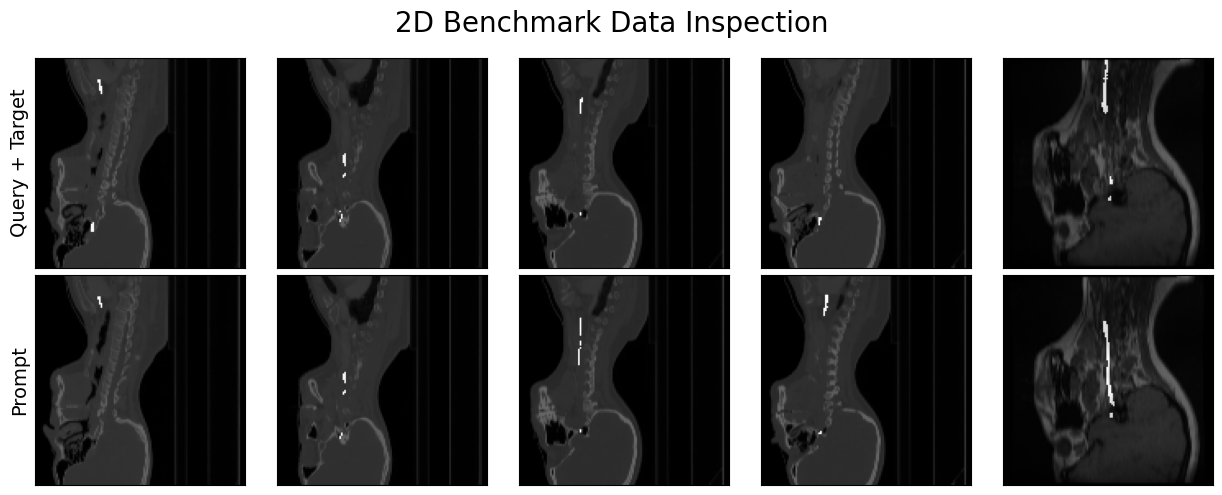

In [4]:
# Corrected path to a specific TFRecord file
dataset_path = str(project_root / "data/test_data/2d/offset_5/0_combined.tfrecord")

if not os.path.exists(dataset_path):
    print(f"Warning: Dataset not found at {dataset_path}")
    print("Searching for available files in the directory...")
    search_dir = os.path.dirname(dataset_path)
    if os.path.exists(search_dir):
        files = [f for f in os.listdir(search_dir) if f.endswith('.tfrecord')]
        if files:
            dataset_path = os.path.join(search_dir, files[0])
            print(f"Using alternative file found: {dataset_path}")
        else:
            print("No .tfrecord files found. Please check data/test_data/2d/offset_5/")
            dataset_path = None
    else:
        print(f"Directory does not exist: {search_dir}")
        dataset_path = None

if dataset_path:
    # Load dataset with offset included
    ds = load_tf_dataset_2D(dataset_path, include_offset=False)
    
    # Visualize 4 random samples
    print("Showing 4 samples from the dataset:")
    visualize_dataset(ds.shuffle(100), max_samples=5, title="2D Benchmark Data Inspection")

Showing 4 samples from the dataset:


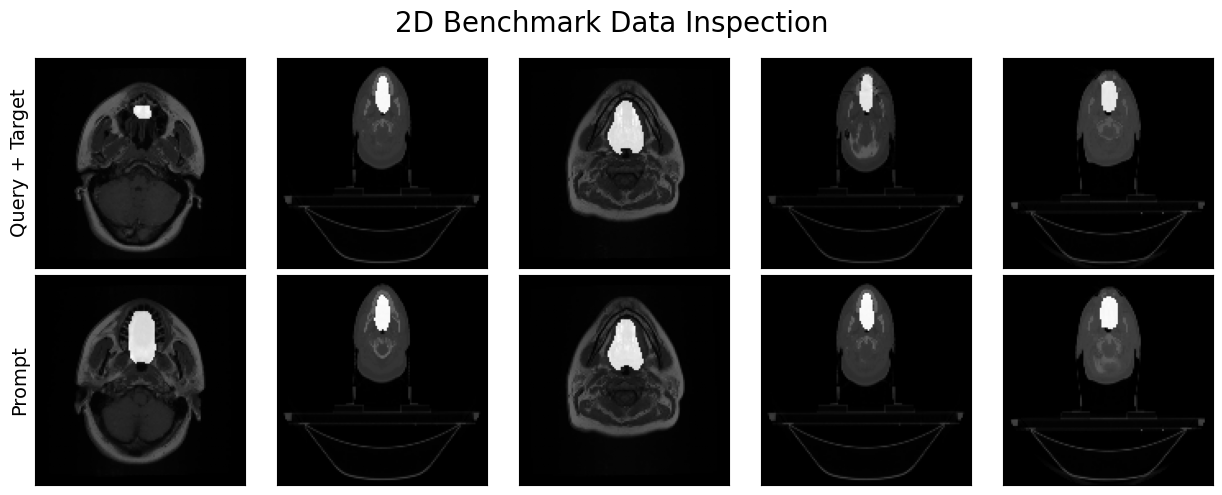

In [5]:
# Corrected path to a specific TFRecord file
dataset_path = str(project_root / "data/test_data/2d/offset_5/7_combined.tfrecord")

if not os.path.exists(dataset_path):
    print(f"Warning: Dataset not found at {dataset_path}")
    print("Searching for available files in the directory...")
    search_dir = os.path.dirname(dataset_path)
    if os.path.exists(search_dir):
        files = [f for f in os.listdir(search_dir) if f.endswith('.tfrecord')]
        if files:
            dataset_path = os.path.join(search_dir, files[0])
            print(f"Using alternative file found: {dataset_path}")
        else:
            print("No .tfrecord files found. Please check data/test_data/2d/offset_5/")
            dataset_path = None
    else:
        print(f"Directory does not exist: {search_dir}")
        dataset_path = None

if dataset_path:
    # Load dataset with offset included
    ds = load_tf_dataset_2D(dataset_path, include_offset=False)
    
    # Visualize 4 random samples
    print("Showing 4 samples from the dataset:")
    visualize_dataset(ds.shuffle(100), max_samples=5, title="2D Benchmark Data Inspection")

Showing 4 samples from the dataset:


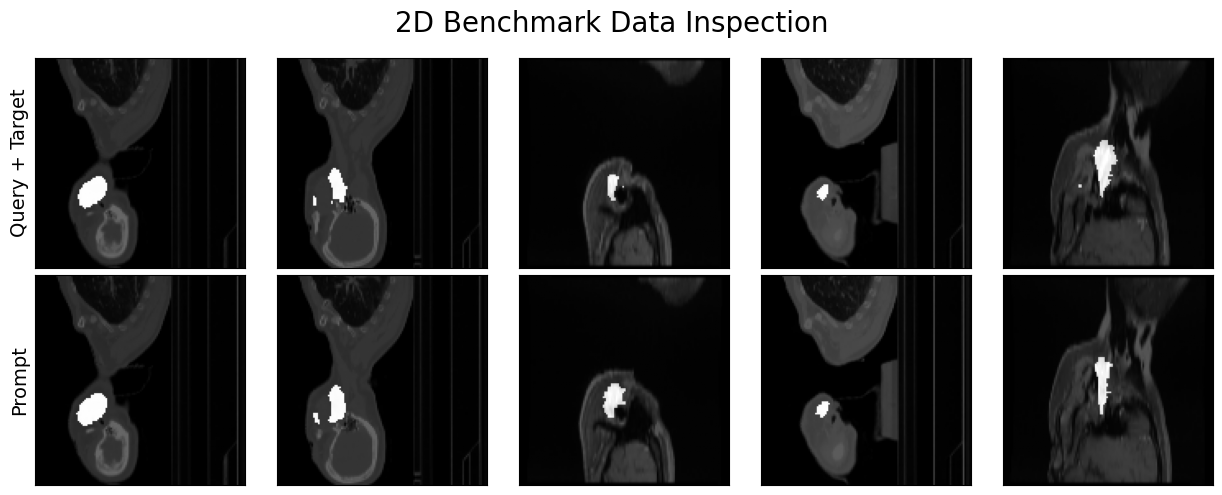

In [7]:
# Corrected path to a specific TFRecord file
dataset_path = str(project_root / "data/test_data/2d/offset_5/4_combined.tfrecord")

if not os.path.exists(dataset_path):
    print(f"Warning: Dataset not found at {dataset_path}")
    print("Searching for available files in the directory...")
    search_dir = os.path.dirname(dataset_path)
    if os.path.exists(search_dir):
        files = [f for f in os.listdir(search_dir) if f.endswith('.tfrecord')]
        if files:
            dataset_path = os.path.join(search_dir, files[0])
            print(f"Using alternative file found: {dataset_path}")
        else:
            print("No .tfrecord files found. Please check data/test_data/2d/offset_5/")
            dataset_path = None
    else:
        print(f"Directory does not exist: {search_dir}")
        dataset_path = None

if dataset_path:
    # Load dataset with offset included
    ds = load_tf_dataset_2D(dataset_path, include_offset=False)
    
    # Visualize 4 random samples
    print("Showing 4 samples from the dataset:")
    visualize_dataset(ds.shuffle(100), max_samples=5, title="2D Benchmark Data Inspection")